In [1]:
import numpy as np
import os
import torch
import torchaudio

print("Torch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)

if torch.cuda.is_available():
    print("CUDA available")
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA unavailable")


Torch version: 2.5.1
Torchaudio version: 2.5.1
CUDA available
GPU count: 1
GPU device: NVIDIA GeForce GTX 1050


## Load Dataset

Feature batch shape: torch.Size([1, 1, 117761])
Labels batch shape: torch.Size([1, 3])


c:\Users\emith\OneDrive - Instituto Politecnico Nacional\Tesis\Programas\SER-Experiments\audioprocessing.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


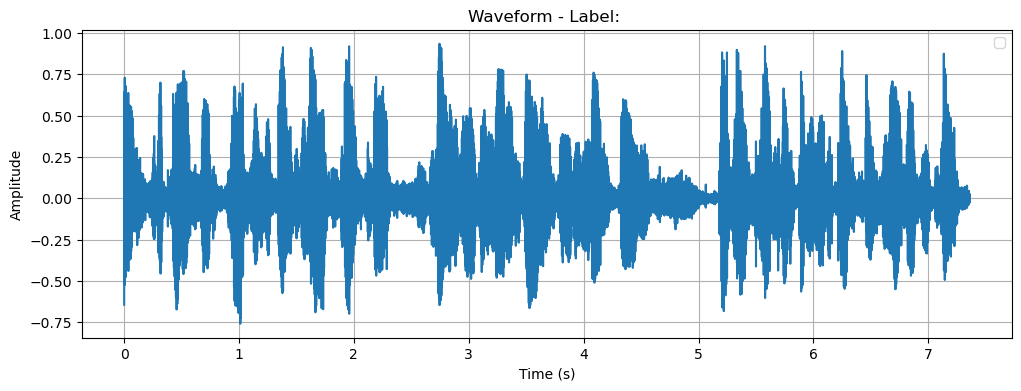

In [1]:
import audioprocessing
from torch.utils.data import DataLoader

msp_vad_train = audioprocessing.AudioDatasetVAD(r"C:\Datasets\_compiled\msp-podcast-2\labels_train_VAD.csv", 
                                                r"C:\Datasets\_compiled\msp-podcast-2\Train")
msp_vad_dev = audioprocessing.AudioDatasetVAD(r"C:\Datasets\_compiled\msp-podcast-2\labels_development_VAD.csv",
                                              r"C:\Datasets\_compiled\msp-podcast-2\Development")
train_dataloader = DataLoader(msp_vad_train, batch_size=1, shuffle=True)
dev_dataloader = DataLoader(msp_vad_dev, batch_size=1, shuffle=True)

train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

waveform = train_features[0]
label = train_labels[0]
audioprocessing.Plot.waveform(waveform, 16000, title=f"Waveform - Label: ")